In [1]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

In [3]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

In [4]:
#Loading data into a DataFrame
train=pd.read_csv("C:/Users/HP/Downloads/cleaned hotel booking datasets/Hotel_A_Train_Cleaned (4).csv")
val=pd.read_csv("C:/Users/HP/Downloads/cleaned hotel booking datasets/Hotel_A_Validation_Cleaned (3).csv")

In [5]:
train = train.drop(['Reservation-id','Expected_checkin', 'Expected_checkout', 'Booking_date'], axis=1)
val = val.drop(['Reservation-id', 'Expected_checkin', 'Expected_checkout', 'Booking_date'], axis=1)

In [6]:
#Defining the target variable
target = "Reservation_Status"

# Training data
X_train = train.drop(columns=[target])
y_train = train[target]

# Validation data
X_validation = val.drop(columns=[target])
y_validation = val[target]

Checking MI Score to Reduce Noise

In [7]:
from sklearn.feature_selection import mutual_info_classif
# This returns a score for every column
mi_scores = mutual_info_classif(X_train, y_train)
mi_scores = pd.DataFrame({'Variable': X_train.columns, 'MI_Score': mi_scores})
mi_scores = mi_scores.sort_values(by='MI_Score', ascending=False).reset_index(drop=True)
mi_scores

,Variable,MI_Score
0,Meal_Type_fb,0.018430
1,Lead_Time,0.016536
2,Booking_channel_online,0.006455
3,Checkin_Month,0.006019
4,Gender_m,0.005834
5,Total_Guests,0.004747
6,Use_Promotion_yes,0.004067
7,Income_>100k,0.003640
8,Deposit_type_non-refundable,0.003603
9,Required_Car_Parking_yes,0.003527


In [8]:
train = train.drop(['Previous_Cancellations_yes','Visted_Previously_yes', 'Country_region_south', 'Meal_Type_hb','Checkin_Month','Ethnicity_caucasian','Ethnicity_asian american','Income_<25k','Length_of_Stay'], axis=1)
val = val.drop(['Previous_Cancellations_yes','Visted_Previously_yes', 'Country_region_south', 'Meal_Type_hb','Checkin_Month','Ethnicity_caucasian','Ethnicity_asian american','Income_<25k','Length_of_Stay'], axis=1)

In [9]:
X_train = pd.get_dummies(X_train)
X_validation = pd.get_dummies(X_validation)

X_validation = X_validation.reindex(columns=X_train.columns, fill_value=0)

In [10]:
# Encode target labels
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_validation = le.transform(y_validation)

In [11]:
# Convert to one-hot encoding
y_train_cat = to_categorical(y_train)
y_validation_cat = to_categorical(y_validation)

In [12]:

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_validation_scaled = scaler.transform(X_validation)

In [13]:
#class weights for class imbalance
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

custom_weights = dict(enumerate(class_weights))
custom_weights

{0: np.float64(0.43305734732518214),
 1: np.float64(2.189954560207725),
 2: np.float64(4.269735801297263)}

In [14]:
def f1_macro(y_true, y_pred):
    y_pred_labels = tf.argmax(y_pred, axis=1)
    y_true_labels = tf.argmax(y_true, axis=1)

    # True positives, predicted positives, actual positives
    tp = tf.math.count_nonzero(y_pred_labels * y_true_labels, dtype=tf.float32)
    predicted_positives = tf.math.count_nonzero(y_pred_labels, dtype=tf.float32)
    actual_positives = tf.math.count_nonzero(y_true_labels, dtype=tf.float32)

    precision = tp / (predicted_positives + 1e-8)
    recall = tp / (actual_positives + 1e-8)
    f1 = 2 * (precision * recall) / (precision + recall + 1e-8)
    return f1

In [15]:
import tensorflow as tf

def focal_loss(gamma=2., alpha=4.):
    def focal_loss_fixed(y_true, y_pred):
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
        # Calculate Cross Entropy
        cross_entropy = -y_true * tf.math.log(y_pred)
        # Calculate Focal Loss
        loss = alpha * tf.pow(1. - y_pred, gamma) * cross_entropy
        return tf.reduce_sum(loss, axis=1)
    return focal_loss_fixed

In [16]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(3, activation='softmax')
])


c:\Users\HP\OneDrive\anaconda\envs\DataScience\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
from tensorflow.keras.optimizers import Adam

model.compile(optimizer=Adam(learning_rate=0.00001),
            loss= 'categorical_crossentropy',
            metrics=[f1_macro])

In [18]:
history = model.fit(
    X_train_scaled, y_train_cat,
    validation_data=(X_validation_scaled , y_validation_cat),
    epochs=55,
    batch_size=64,
    class_weight=custom_weights,
    #callbacks=[early_stop],
    verbose=1
)

Epoch 1/55
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - f1_macro: 0.3417 - loss: 1.2508 - val_f1_macro: 0.5216 - val_loss: 1.3263
Epoch 2/55
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - f1_macro: 0.3426 - loss: 1.2198 - val_f1_macro: 0.5177 - val_loss: 1.2941
Epoch 3/55
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - f1_macro: 0.3422 - loss: 1.1957 - val_f1_macro: 0.5164 - val_loss: 1.2623
Epoch 4/55
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - f1_macro: 0.3434 - loss: 1.1790 - val_f1_macro: 0.5114 - val_loss: 1.2392
Epoch 5/55
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - f1_macro: 0.3405 - loss: 1.1673 - val_f1_macro: 0.5061 - val_loss: 1.2192
Epoch 6/55
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - f1_macro: 0.3402 - loss: 1.1579 - val_f1_macro: 0.5117 - val_loss: 1.2061
Epoch 7/55
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - f1_macro: 0.3444 - loss: 1.1492 - val_f1_macro: 0.5105 - val_loss: 1.1942
Epoch 8/55
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - f1_macro: 0.3435 - loss: 1.1443 - val_f1_macro: 0.

In [19]:
pred_probs = model.predict(X_validation_scaled)
y_pred = np.argmax(pred_probs, axis=1)

print("\n--- Final Validation Report ---")
print(classification_report(y_validation, y_pred, target_names=['check-in', 'cancelation', 'no-show']))

86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

--- Final Validation Report ---
              precision    recall  f1-score   support

    check-in       0.61      0.41      0.49      1602
 cancelation       0.28      0.30      0.29       738
     no-show       0.15      0.32      0.20       393

    accuracy                           0.37      2733
   macro avg       0.34      0.34      0.33      2733
weighted avg       0.45      0.37      0.39      2733



In [20]:
from sklearn.metrics import classification_report

# Evaluate train
y_pred = np.argmax(model.predict(X_train_scaled), axis=1)
print("\n--- Final Train Report ---")
print(classification_report(y_train, y_pred, target_names=['Check-in', 'Cancellation', 'No-show']))

844/844 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

--- Final Train Report ---
              precision    recall  f1-score   support

    Check-in       0.83      0.50      0.62     20774
Cancellation       0.20      0.38      0.26      4108
     No-show       0.11      0.35      0.17      2107

    accuracy                           0.47     26989
   macro avg       0.38      0.41      0.35     26989
weighted avg       0.67      0.47      0.53     26989



In [21]:
#from sklearn.metrics import classification_report

# Evaluate
#y_pred = np.argmax(model.predict(X_validation_scaled), axis=1)
#print(classification_report(y_validation, y_pred, target_names=['Check-in', 'Cancellation', 'No-show']))

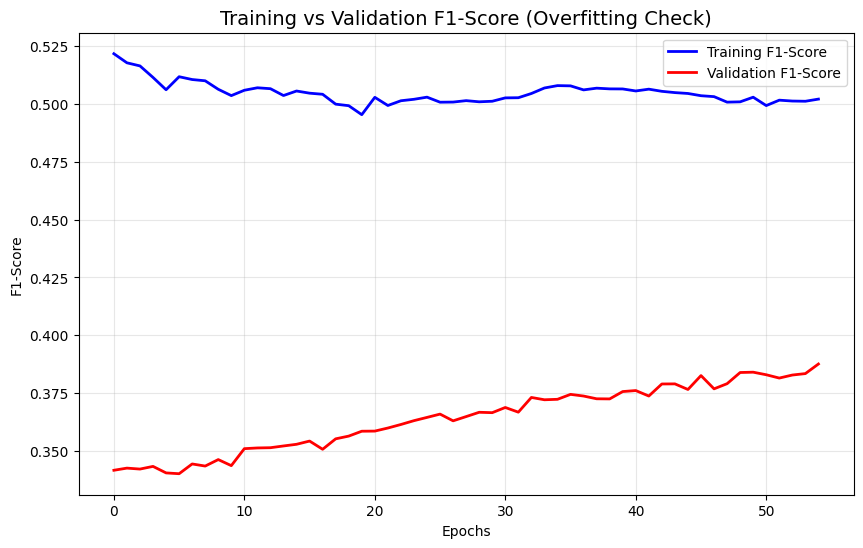

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Plot Training F1
plt.plot(history.history['val_f1_macro'], label='Training F1-Score', color='blue', linewidth=2)

# Plot Validation F1
plt.plot(history.history['f1_macro'], label='Validation F1-Score', color='red', linewidth=2)

plt.title('Training vs Validation F1-Score (Overfitting Check)', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('F1-Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [23]:
from xgboost import XGBClassifier
from sklearn.utils import class_weight
import numpy as np

classes_weights = class_weight.compute_sample_weight(
    class_weight='balanced',
    y=y_train
)

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    objective='multi:softprob',
    random_state=42
)

xgb_model.fit(X_train_scaled, y_train, sample_weight=classes_weights)

y_pred_xgb = xgb_model.predict(X_validation_scaled)
print(classification_report(y_validation, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.59      0.41      0.49      1602
           1       0.28      0.33      0.30       738
           2       0.14      0.28      0.19       393

    accuracy                           0.37      2733
   macro avg       0.34      0.34      0.33      2733
weighted avg       0.44      0.37      0.39      2733



In [24]:
nn_probs = model.predict(X_validation_scaled)
xgb_probs = xgb_model.predict_proba(X_validation_scaled)

final_probs = (nn_probs + xgb_probs) / 2

final_preds = np.argmax(final_probs, axis=1)

print("--- Ensemble Model Report ---")
print(classification_report(y_validation, final_preds))

86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
--- Ensemble Model Report ---
              precision    recall  f1-score   support

           0       0.61      0.44      0.51      1602
           1       0.30      0.31      0.30       738
           2       0.15      0.31      0.20       393

    accuracy                           0.39      2733
   macro avg       0.35      0.35      0.34      2733
weighted avg       0.46      0.39      0.41      2733



In [25]:
X_train.columns

Index(['Age', 'Discount_Rate', 'Room_Rate', 'Lead_Time', 'Length_of_Stay',
       'Total_Guests', 'Checkin_Month', 'Is_Weekend', 'Gender_m',
       'Ethnicity_asian american', 'Ethnicity_caucasian', 'Ethnicity_latino',
       'Educational_Level_grad', 'Educational_Level_high-school',
       'Educational_Level_mid-school', 'Income_50k -- 100k', 'Income_<25k',
       'Income_>100k', 'Country_region_north', 'Country_region_south',
       'Country_region_west', 'Hotel_Type_city hotel', 'Hotel_Type_resort',
       'Meal_Type_fb', 'Meal_Type_hb', 'Visted_Previously_yes',
       'Previous_Cancellations_yes', 'Deposit_type_non-refundable',
       'Deposit_type_refundable', 'Booking_channel_direct',
       'Booking_channel_online', 'Required_Car_Parking_yes',
       'Use_Promotion_yes'],
      dtype='object')

## Final Prediction

In [26]:
test= pd.read_csv("C:/Users/HP/Downloads/cleaned hotel booking datasets/Hotel_A_Test_Cleaned.csv")

In [27]:
test= test.drop(['Reservation-id','Expected_checkin', 'Expected_checkout', 'Booking_date'], axis=1)

In [28]:
test = pd.get_dummies(test)

In [29]:
test = test.reindex(columns=X_train.columns, fill_value=0)

In [30]:
test_scaled = scaler.transform(test)

In [31]:
y_pred_probs = model.predict(test_scaled)

135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [32]:
import numpy as np

y_pred = np.argmax(y_pred_probs, axis=1)

In [33]:
y_pred = le.inverse_transform(y_pred)

In [36]:
# Add predictions
test['Predicted_Status'] = y_pred

# Convert numbers to labels
mapping = {
    1: "Check-in",
    2: "Cancel",
    3: "No-show"
}

test['Predicted_Status'] = test['Predicted_Status'].map(mapping)

# Save file
test.to_csv("final_predictions.csv", index=False)